In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
import ast # string olarak saklanan listeleri gerçek listelere dönüştürmek için

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [2]:
data = pd.read_csv('../../data/data.csv')

In [3]:
config = {
    'alerjenler': 10,          
    'eser_miktarlar': 50,  
    'kategori_listesi': 50,   
    'etiketler_listesi': 50,
}

def convert_to_list(x):
    if pd.isna(x): return []
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

for col, min_count in config.items():
    if col in data.columns:
        data[col] = data[col].apply(convert_to_list)
        counts = data[col].explode().value_counts()
        valid_elements = counts[counts >= min_count].index.tolist()
        data[col] = data[col].apply(lambda x: [i for i in x if i in valid_elements])
        mlb = MultiLabelBinarizer()
        encoded = mlb.fit_transform(data[col])
        col_names = [f"{col}_{str(c).strip().replace(' ', '_')}" for c in mlb.classes_]
        encoded_df = pd.DataFrame(encoded, columns=col_names, index=data.index)
        data = pd.concat([data, encoded_df], axis=1)
        print(f"Bitti! {len(col_names)} adet yeni kolon eklendi. {col}")

Bitti! 45 adet yeni kolon eklendi. alerjenler
Bitti! 14 adet yeni kolon eklendi. eser_miktarlar
Bitti! 734 adet yeni kolon eklendi. kategori_listesi
Bitti! 237 adet yeni kolon eklendi. etiketler_listesi


In [4]:

data['markalar'] = data['markalar'].astype(str).str.lower().str.strip()
marka_counts = data['markalar'].value_counts()

valid_markalar = marka_counts[marka_counts >= 50].index.tolist()

for marka in valid_markalar:
    clean_marka_name = marka.replace(' ', '_').replace('.', '').replace('-', '_')
    data[f'marka_{clean_marka_name}'] = (data['markalar'] == marka).astype(int)

print(f"Bitti! 50'den fazla ürünü olan {len(valid_markalar)} marka için yeni kolonlar eklendi.")

Bitti! 50'den fazla ürünü olan 146 marka için yeni kolonlar eklendi.


In [5]:
def standardize_unit(row):
    u = str(row['birim']).lower().strip()
    miktar = row['miktar']
    
    # Sıvılar -> ML cinsinden standartlaştırma
    if u in ['l', 'litre', 'litro', 'litri', 'liter', 'litros', 'litres', 'litra']:
        return miktar * 1000  
    if u == 'cl':
        return miktar * 10  
    if u in ['ml', 'fl']:
        return miktar        
        

    if u == 'kg':
        return miktar * 1000
    if u in ['oz', 'ounces']:
        return miktar * 28.35 
    if u in ['lb', 'lbs', 'pounds']:
        return miktar * 453.59 
    if u in ['g', 'gram', 'grams', 'gm']:
        return miktar        
        
    return miktar

data['miktar_standart'] = data.apply(standardize_unit, axis=1)

def categorize_unit(u):
    u = str(u).lower().strip()
    if u in ['l', 'cl', 'ml', 'litre', 'fl']: return 2 # Sıvı
    if u in ['g', 'kg', 'gram', 'lb', 'oz']: return 1  # Katı
    return 0 # Belirsiz

data['birim_tipi'] = data['birim'].apply(categorize_unit)

vegan_map = {'yes': 1, 'maybe': 0.5, 'no': 0}
data['vegan_durumu'] = data['vegan_durumu'].map(vegan_map).fillna(0)

# 3. Yeşil Skor Mapping
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
data['yesil_skor_notu'] = data['yesil_skor_notu'].map(grade_map).fillna(2) # Bilinmiyorsa orta değer C(2)

# 4. Boolean (True/False) Dönüşümü
data['vejetaryen'] = data['vejetaryen'].astype(float).fillna(0)
data['palmiye_yagi_icermez'] = data['palmiye_yagi_icermez'].astype(float).fillna(0)

In [6]:
# Harfleri sayıya çevirelim
mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
data['nutriscore_notu'] = data['nutriscore_notu'].map(mapping)

# Eğer Nutriscore'u boş olan satırlar varsa onları da silelim:
data = data.dropna(subset=['nutriscore_notu'])

In [7]:
data.drop(columns=["eser_miktarlar","kategori_listesi","alerjenler","etiketler_listesi","markalar","birim"], inplace=True)

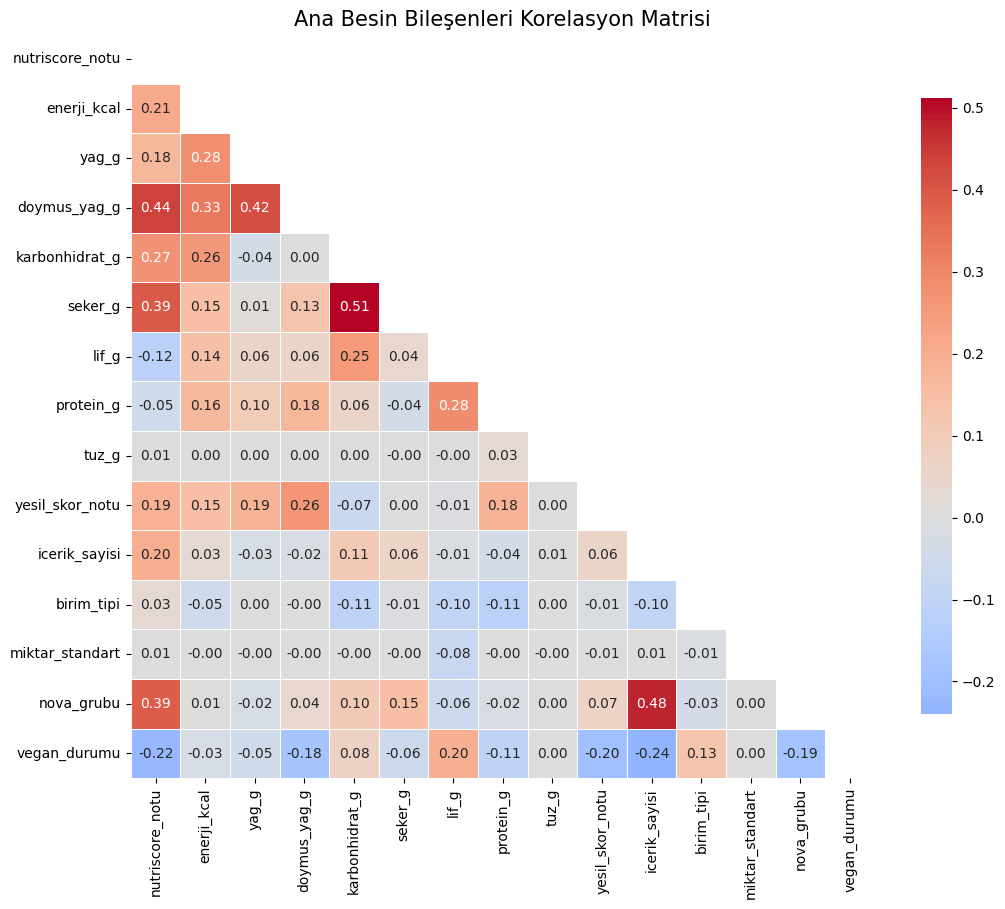

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sadece sayısal ve anlamlı ana sütunları seçelim 
# (Yüzlerce kategori sütununu matrise eklersek okunmaz hale gelir)
core_columns = [
    'nutriscore_notu', 'enerji_kcal', 'yag_g', 'doymus_yag_g', 
    'karbonhidrat_g', 'seker_g', 'lif_g', 'protein_g', 'tuz_g',
    'yesil_skor_notu', 'icerik_sayisi', 'birim_tipi', 'miktar_standart',
    'nova_grubu', 'vegan_durumu'
]

# Mevcut olanları filtrele
available_cols = [c for c in core_columns if c in data.columns]
corr_data = data[available_cols].corr()

# 2. Görselleştirme
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool)) # Üst üçgeni gizle (daha temiz görünür)

sns.heatmap(corr_data, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Ana Besin Bileşenleri Korelasyon Matrisi', fontsize=15)
plt.show()

In [9]:
X = data.drop(columns=['nutriscore_notu', 'barkod'], errors='ignore')
y = data['nutriscore_notu']

In [10]:
y.value_counts()

nutriscore_notu
1.0    15206
4.0    13046
0.0    11938
2.0    11628
3.0    11407
Name: count, dtype: int64

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [12]:
"""En İyi Parametreler ve Ağırlıklar:
weight_A: 3.1157540748813943
weight_B: 9.267941372717193
weight_C: 6.525637137473273
weight_D: 7.807587203669553
weight_E: 9.378493234488909
iterations: 2586
learning_rate: 0.06710396210335219
depth: 7
l2_leaf_reg: 9.779988447388671
"""

# model = CatBoostClassifier(
#     iterations=2586,
#     learning_rate=0.06710396210335219,
#     depth=7,
#     l2_leaf_reg=9.779988447388671,
#     class_weights=[3.1157540748813943, 9.267941372717193, 6.525637137473273, 7.807587203669553, 9.378493234488909],
#     loss_function='MultiClass',
#     eval_metric='MultiClass',
#     random_seed=42,
#     verbose=100,
#     allow_writing_files=False
# )

# birde class weights olmadan model oluştur
model = CatBoostClassifier(
    iterations=2586,
    learning_rate=0.06710396210335219,
    depth=7,
    l2_leaf_reg=9.779988447388671,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))


y_pred = model.predict(X_test)

0:	learn: 1.5355110	test: 1.5360935	best: 1.5360935 (0)	total: 123ms	remaining: 5m 19s
100:	learn: 0.6066104	test: 0.6139803	best: 0.6139803 (100)	total: 7.91s	remaining: 3m 14s
200:	learn: 0.4990343	test: 0.5092806	best: 0.5092806 (200)	total: 16.3s	remaining: 3m 13s
300:	learn: 0.4377829	test: 0.4528520	best: 0.4528520 (300)	total: 23.6s	remaining: 2m 58s
400:	learn: 0.4029830	test: 0.4221774	best: 0.4221774 (400)	total: 30.8s	remaining: 2m 48s
500:	learn: 0.3803262	test: 0.4033211	best: 0.4033211 (500)	total: 38.2s	remaining: 2m 38s
600:	learn: 0.3637034	test: 0.3904181	best: 0.3904181 (600)	total: 45.7s	remaining: 2m 31s
700:	learn: 0.3503522	test: 0.3804637	best: 0.3804637 (700)	total: 53.1s	remaining: 2m 22s
800:	learn: 0.3393547	test: 0.3723951	best: 0.3723951 (800)	total: 1m	remaining: 2m 15s
900:	learn: 0.3293853	test: 0.3652819	best: 0.3652819 (900)	total: 1m 8s	remaining: 2m 7s
1000:	learn: 0.3213532	test: 0.3597068	best: 0.3597068 (1000)	total: 1m 15s	remaining: 1m 59s
1100

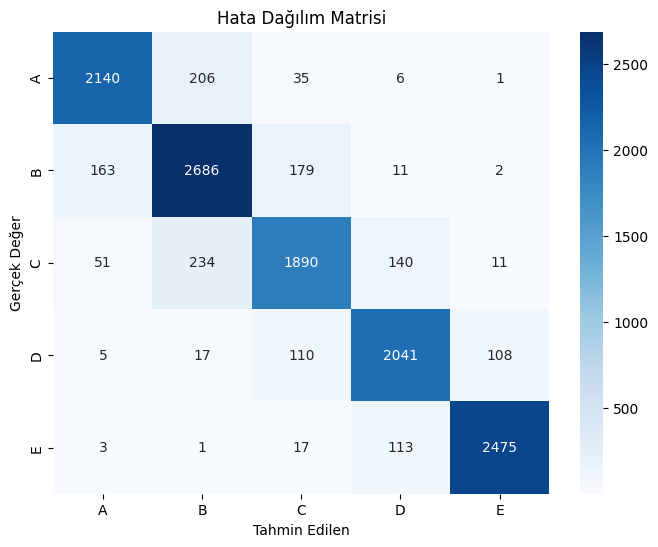

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['A', 'B','C','D', 'E'], 
            yticklabels=['A', 'B','C','D', 'E'])
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('Hata Dağılım Matrisi')
plt.show()

In [14]:
print("\n--- CatBoost Model Performansı ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['A', 'B','C','D', 'E']))

# 7. Özellik Önem Sıralaması (Hangi kolon etkili?)
feature_importance = model.get_feature_importance(type="FeatureImportance")
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance}).sort_values(by='Importance', ascending=False)

print("\nEn Etkili 10 Kolon:")
print(importance_df.head(10))


--- CatBoost Model Performansı ---
Accuracy: 0.8883

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           A       0.91      0.90      0.90      2388
           B       0.85      0.88      0.87      3041
           C       0.85      0.81      0.83      2326
           D       0.88      0.89      0.89      2281
           E       0.95      0.95      0.95      2609

    accuracy                           0.89     12645
   macro avg       0.89      0.89      0.89     12645
weighted avg       0.89      0.89      0.89     12645


En Etkili 10 Kolon:
                        Feature  Importance
14                        tuz_g   17.002477
9                  doymus_yag_g   15.075478
11                      seker_g   14.525181
7                   enerji_kcal    8.324984
13                    protein_g    7.706380
12                        lif_g    6.554732
107  kategori_listesi_Beverages    4.578809
10               karbonhidrat_g    4.463198
8                 